In [8]:
import sys
sys.path.append("/home/gsommani/alertstack/lib/python3.12/site-packages/")
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats
from scipy.stats import distributions, uniform
from astropy.coordinates import angular_separation

In [2]:
def mykstest_lons(data):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = np.sort(data)/360.
    diffs = np.abs(s-cumul_data)
    ts = np.max(diffs)
    pval = distributions.kstwo.sf(ts, len(data))
    return pval

def cdf_lats(x):
    x = np.sin(np.deg2rad(x))
    cut_lat = 10.
    cut_lat_rad = np.deg2rad(cut_lat)
    norm = 2*(1-np.sin(cut_lat_rad))
    cdf = np.empty(len(x))
    cdf[x<=np.sin(-cut_lat_rad)] = (x[x<=np.sin(-cut_lat_rad)] + 1) / norm
    cdf[x>=np.sin(cut_lat_rad)] = (
        x[x>=np.sin(cut_lat_rad)] + 1 - 2 * np.sin(cut_lat_rad)
    ) / norm
    return cdf

def mykstest_lats(data):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = cdf_lats(np.sort(data))
    diffs = np.abs(s-cumul_data)
    ts = np.max(diffs)
    pval = distributions.kstwo.sf(ts, len(data))
    return pval

def mykstest_lon_lat(cat, print_pvals=True):
    pval_lon = mykstest_lons(cat["GLON"])
    pval_lat = mykstest_lats(cat["GLAT"])
    if print_pvals:
        print(f"KS test, pval latitude: {pval_lat}.\t pval longitude: {pval_lon}")
    return pval_lat, pval_lon

def weighted_means_stds_lats(cat):
    cdf = stats.ecdf(cat["Energy_Flux100"]).cdf
    probs = cdf.probabilities[:-1] - cdf.probabilities[1:]
    all_vals = []
    for i in range(200):
        rnd_weights = stats.rv_histogram(
            (probs, cdf.quantiles)
        ).rvs(size=len(cat))
        rnd_lat_pos = uniform.rvs(
            size=int(len(cat["GLAT"])/2.)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
        addition = 0
        if len(cat["GLAT"])%2 != 0.:
            addition = 1
        rnd_lat_neg = - ( uniform.rvs(
            size=int(len(cat["GLAT"])/2. + addition)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
        rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
        vals, quantiles, _ = plt.hist(
            rnd_lat, bins=20, weights=rnd_weights, density=True
        )
        plt.close()
        all_vals.append(vals)
    all_vals = np.array(all_vals)
    means = np.array([np.mean(all_vals[:,i]) for i in range(len(all_vals[0]))])
    stds = np.array([np.std(all_vals[:,i]) for i in range(len(all_vals[0]))])
    xs = (quantiles[:-1] + quantiles[1:])/2.

    return means, stds, xs

def weighted_means_stds_lons(cat):
    cdf = stats.ecdf(cat["Energy_Flux100"]).cdf
    probs = cdf.probabilities[:-1] - cdf.probabilities[1:]
    all_vals = []
    for i in range(200):
        rnd_weights = stats.rv_histogram(
            (probs, cdf.quantiles)
        ).rvs(size=len(cat))
        rnd_lon = uniform.rvs(
            size=int(len(cat["GLON"]))
        ) * 360.
        vals, quantiles, _ = plt.hist(
            rnd_lon, bins=20, weights=rnd_weights, density=True
        )
        plt.close()
        all_vals.append(vals)
    all_vals = np.array(all_vals)
    means = np.array([np.mean(all_vals[:,i]) for i in range(len(all_vals[0]))])
    stds = np.array([np.std(all_vals[:,i]) for i in range(len(all_vals[0]))])
    xs = (quantiles[:-1] + quantiles[1:])/2.

    return means, stds, xs

In [7]:
def perform_cuts_studies(name_cat = "table_4LAC.fits"):

    alertstack_data_dir = "../../alertstack/data/"
    with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
        cat = hdul[1].data
        header = hdul[1].header
    cat = np.sort(cat, order="Energy_Flux100")[::-1]
    
    #blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    
    mask = np.array([x["CLASS"] in blazar_class for x in cat])
    blazars = np.array(cat[mask])
    
    blazars_cuts = list()
    pvals_lats = list()
    pvals_lons = list()
    for i in range(5):
        cut_e = -12. + 0.1*i
        mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
        blazars_cut = np.array(blazars[mask_e])
        surviving_flux = np.sum(blazars_cut["Energy_Flux100"])
        total_flux = np.sum(blazars["Energy_Flux100"])
        surviving_flux_ratio = surviving_flux / total_flux
        print(f"cut_e: {cut_e}\tSurviving blazars: {len(blazars_cut)}\tSurviving flux: {surviving_flux_ratio}")
        blazars_cuts.append(blazars_cut)
        pval_lat, pval_lon = mykstest_lon_lat(blazars_cut)
        pvals_lats.append(pval_lat)
        pvals_lons.append(pval_lon)
    
    rnd_lat_pos = uniform.rvs(
        size=int(len(blazars_cuts[-1]["GLAT"])/2.)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
    rnd_lat_neg = - ( uniform.rvs(
        size=int(len(blazars_cuts[-1]["GLAT"])/2.)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)) )
    rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
    
    plt.hist(
        rnd_lat,
        bins=20, density=True,
        color="white",
        label="cut, p-value"
    )
    plt.hist(
        rnd_lat,
        bins=20, density=True,
    )
    
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lats[i]
        catcut = blazars_cuts[i]
        plt.hist(
            np.sin(np.deg2rad(catcut["GLAT"])),
            bins=20, histtype='step', density=True,
            label=f"{cut_e} {round(pval,2):.2f}", linewidth=2,
        )
    
    plt.xlabel("sin(b)")
    plt.ylabel("Density")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/data/{name_cat.split('.')[0]}_lat",
        dpi=200,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.close()
    
    rnd_lon = uniform.rvs(
        size=int(len(blazars_cuts[-1]["GLON"]))
    ) * 360.
    
    plt.hist(
        rnd_lon,
        bins=20, density=True,
        color="white",
        label="cut, p-value"
    )
    plt.hist(
        rnd_lon,
        bins=20, density=True,
    )
    
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lons[i]
        catcut = blazars_cuts[i]
        plt.hist(
            catcut["GLON"],
            bins=20, histtype='step', density=True,
            label=f"{cut_e} {round(pval,2):.2f}", linewidth=2,
        )
    
    plt.xlabel("longitude [deg]")
    plt.ylabel("Density [deg-1]")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/data/{name_cat.split('.')[0]}_lon",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    ### weighted histograms
    
    means, stds, xs = weighted_means_stds_lats(blazars_cuts[-1])
    
    plt.errorbar(
        xs, means, stds, marker='o',
        linestyle="", label="Weighted MC"
    )
    
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lats[i]
        catcut = blazars_cuts[i]
        print(f"cut: {cut_e} ")
        lat_dens, lat_quantiles, _ = plt.hist(
            np.sin(np.deg2rad(catcut["GLAT"])),
            bins=20, histtype='step', density=True,
            label=f"Cut = {cut_e}", linewidth=2,
            weights=catcut["Energy_Flux100"]
        )

    print(((lat_dens[stds!=0.] - means[stds!=0.])/stds[stds!=0.])**2)
    chi_sq = np.sum(((lat_dens[stds!=0.] - means[stds!=0.])/stds[stds!=0.])**2)
    pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(stds[stds!=0.]))
    print(
        "Chi2 result from comparison with weighted expetations:"
        f" {chi_sq}, pval: {pval_chisq}"
    )
  
    plt.xlabel("sin(b)")
    plt.ylabel("Density")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/data/{name_cat.split('.')[0]}_lat_weight",
        dpi=200,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.close()
    
    means, stds, xs = weighted_means_stds_lons(blazars_cuts[-1])
    
    plt.errorbar(
        xs, means, stds, marker='o',
        linestyle="", label="Weighted MC"
    )
        
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lons[i]
        catcut = blazars_cuts[i]
        lon_dens, lon_quantiles, _ = plt.hist(
            catcut["GLON"],
            bins=20, histtype='step', density=True,
            label=f"Cut = {cut_e}", linewidth=2,
            weights=catcut["Energy_Flux100"]
        )

    print(((lon_dens - means)/stds)**2)
    chi_sq = np.sum(((lon_dens - means)/stds)**2)
    pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(lon_dens))
    print(
        "Chi2 result from comparison with weighted expetations:"
        f" {chi_sq}, pval: {pval_chisq}"
    )
    
    plt.xlabel("longitude [deg]")
    plt.ylabel("Density [deg-1]")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/data/{name_cat.split('.')[0]}_lon_weight",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

cut_e: -12.0	Surviving blazars: 2760	Surviving flux: 0.998652458190918
KS test, pval latitude: 1.868985203823115e-05.	 pval longitude: 0.03262472473330258
cut_e: -11.9	Surviving blazars: 2682	Surviving flux: 0.9952264428138733
KS test, pval latitude: 0.0003361089779874717.	 pval longitude: 0.06296728188136858
cut_e: -11.8	Surviving blazars: 2519	Surviving flux: 0.9861823916435242
KS test, pval latitude: 0.0012188363925227548.	 pval longitude: 0.15642201582769577
cut_e: -11.7	Surviving blazars: 2257	Surviving flux: 0.9679204821586609
KS test, pval latitude: 0.02835656357552574.	 pval longitude: 0.234356347747542
cut_e: -11.6	Surviving blazars: 1916	Surviving flux: 0.9380135536193848
KS test, pval latitude: 0.19815885155690915.	 pval longitude: 0.702349312873815


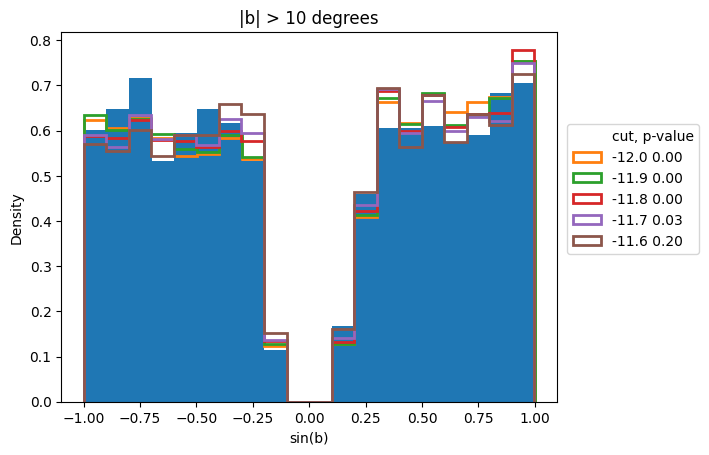

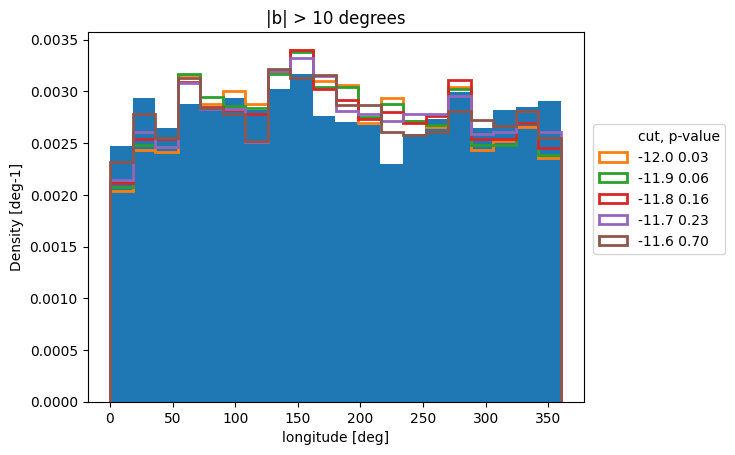

cut: -12.0 
cut: -11.9 
cut: -11.8 
cut: -11.7 
cut: -11.6 
[2.11796446e+00 3.10467076e-01 3.32246394e-01 9.21315974e+00
 1.12116124e-01 1.50712109e-01 5.04510860e-01 6.06451406e-02
 1.70417363e-01 1.05477532e-02 6.10823923e-01 2.55061302e-01
 4.33753194e-01 5.18627542e-01 2.38891860e+00 5.12903198e-01
 8.41413616e-03 5.38857912e+00]
Chi2 result from comparison with weighted expetations: 23.09986803417215, pval: 0.18678152944552595


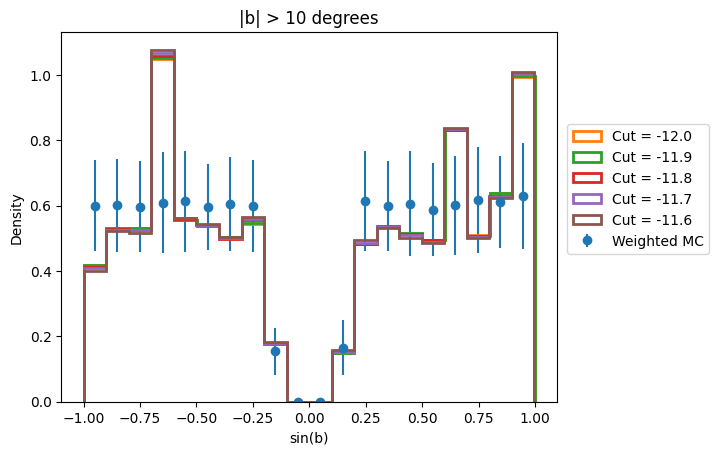

[ 0.18713374  0.0359005   1.64767394  0.37627413 11.84050384  0.18645952
  1.67295441  2.07146102  0.11616982  0.98028414  0.02378271  0.10817348
  0.10470777  0.35890127  0.69915399  1.29216996  0.07033107  0.06880591
  0.45146538  0.14336151]
Chi2 result from comparison with weighted expetations: 22.435668085963417, pval: 0.3173454891497405


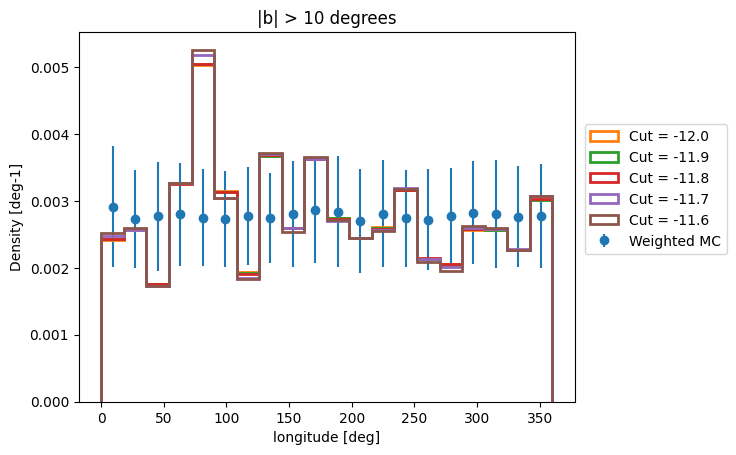

In [8]:
perform_cuts_studies()

cut_e: -12.0	Surviving blazars: 3018	Surviving flux: 0.9986096024513245
KS test, pval latitude: 1.6949086990687172e-05.	 pval longitude: 0.014959552451444539
cut_e: -11.9	Surviving blazars: 2932	Surviving flux: 0.9952530264854431
KS test, pval latitude: 0.00034915666062699906.	 pval longitude: 0.039280892257635314
cut_e: -11.8	Surviving blazars: 2754	Surviving flux: 0.9864620566368103
KS test, pval latitude: 0.0012936318986033588.	 pval longitude: 0.09213164143987573
cut_e: -11.7	Surviving blazars: 2461	Surviving flux: 0.968332052230835
KS test, pval latitude: 0.03187150154912022.	 pval longitude: 0.1669043521438115
cut_e: -11.6	Surviving blazars: 2089	Surviving flux: 0.9393209218978882
KS test, pval latitude: 0.13455105095923903.	 pval longitude: 0.590136769041801


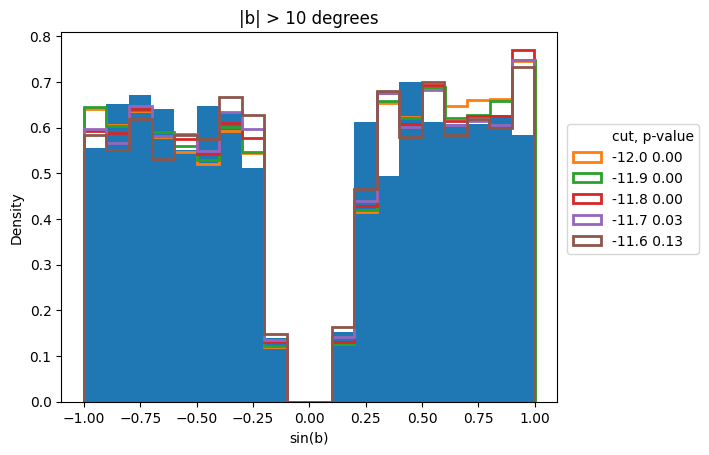

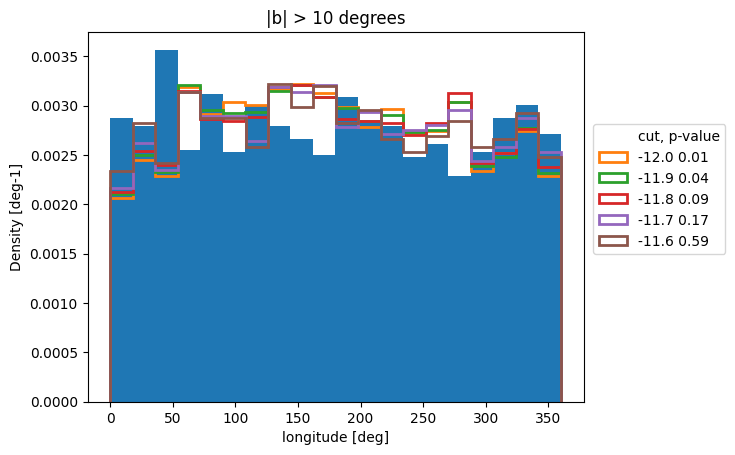

cut: -12.0 
cut: -11.9 
cut: -11.8 
cut: -11.7 
cut: -11.6 
[ 2.03190912  0.50282781  0.40843305 10.43688716  0.31846343  0.21055127
  0.10414438  0.33007539  0.11909647  0.05140735  0.76394711  0.14631965
  0.60721355  0.37764472  1.63751994  0.9424014   1.38206975  6.65931612]
Chi2 result from comparison with weighted expetations: 27.03022766819366, pval: 0.07843027741289199


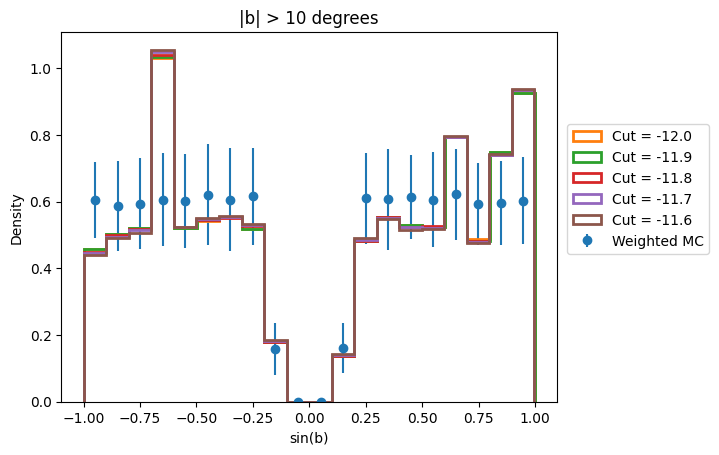

[0.25291358 0.1543785  2.32387566 0.19801582 8.26767688 0.30105871
 0.99169791 1.26512644 0.41071149 2.44718603 0.01753134 0.04393513
 0.0946466  0.1030608  0.11786435 1.5829774  0.48702645 0.03855057
 0.09224079 0.0101506 ]
Chi2 result from comparison with weighted expetations: 19.20062504850787, pval: 0.5088216648756285


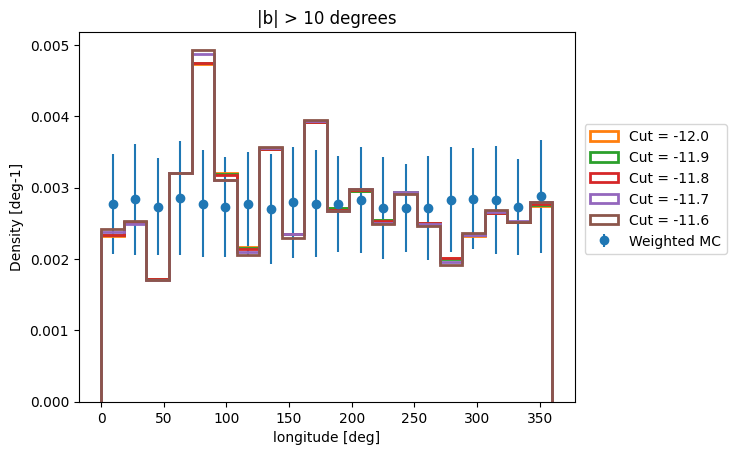

In [9]:
perform_cuts_studies(name_cat="table-4LAC-DR2-h.fits")

cut_e: -12.0	Surviving blazars: 3125	Surviving flux: 0.9936019778251648
KS test, pval latitude: 0.0008191590175466827.	 pval longitude: 0.03992921028528007
cut_e: -11.9	Surviving blazars: 2939	Surviving flux: 0.9854530692100525
KS test, pval latitude: 0.008918809713230336.	 pval longitude: 0.16681297458792965
cut_e: -11.8	Surviving blazars: 2653	Surviving flux: 0.9697197675704956
KS test, pval latitude: 0.01206322415357416.	 pval longitude: 0.35462953797077323
cut_e: -11.7	Surviving blazars: 2269	Surviving flux: 0.9434078335762024
KS test, pval latitude: 0.15022993754688152.	 pval longitude: 0.6370566482893311
cut_e: -11.6	Surviving blazars: 1905	Surviving flux: 0.9118748307228088
KS test, pval latitude: 0.31980838609927675.	 pval longitude: 0.7994032366638005


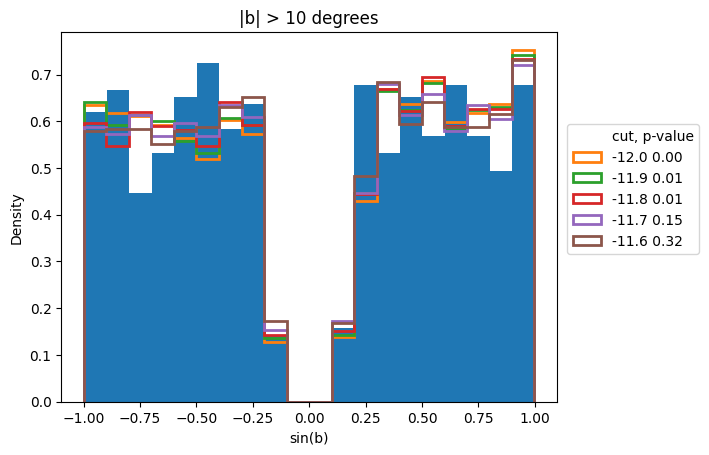

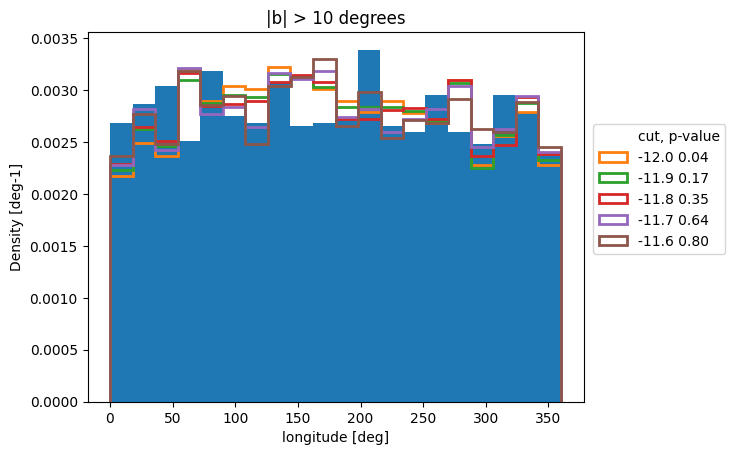

cut: -12.0 
cut: -11.9 
cut: -11.8 
cut: -11.7 
cut: -11.6 
[1.85668483e+00 1.73055308e-02 1.48312484e-01 1.08328414e+01
 3.07732881e-01 2.22421787e-01 5.28317484e-01 9.49429589e-02
 3.38160696e-01 8.65755647e-03 1.08230107e+00 3.22937938e-01
 3.86205750e-01 1.01919819e+00 2.22196850e+00 6.64890490e-01
 2.05727858e-01 5.61420431e+00]
Chi2 result from comparison with weighted expetations: 25.872811766175964, pval: 0.10270181469878126


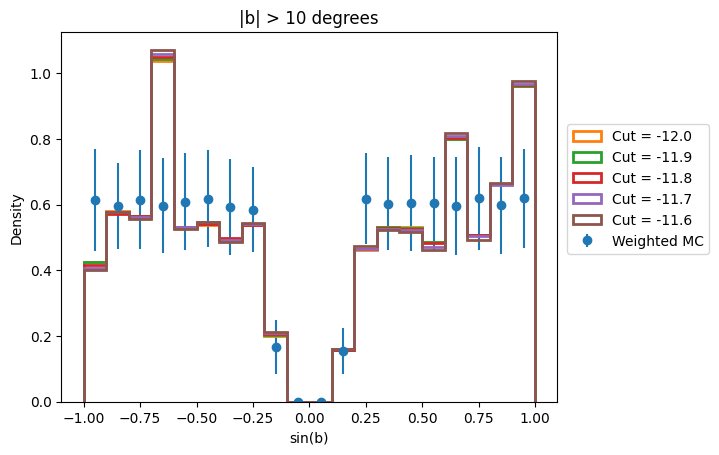

[1.29898496e-01 1.77603890e-02 1.22318669e+00 3.07816060e-01
 8.81756783e+00 3.81731454e-01 1.59089406e+00 1.07030178e+00
 1.15154882e-02 9.34574153e-01 1.35525392e-02 2.13314835e-01
 2.98406105e-03 5.45870044e-02 1.34065261e+00 9.06461804e-01
 7.94722535e-03 1.67021373e-01 5.19347658e-01 1.09251605e-02]
Chi2 result from comparison with weighted expetations: 17.722040668399796, pval: 0.6057130004290578


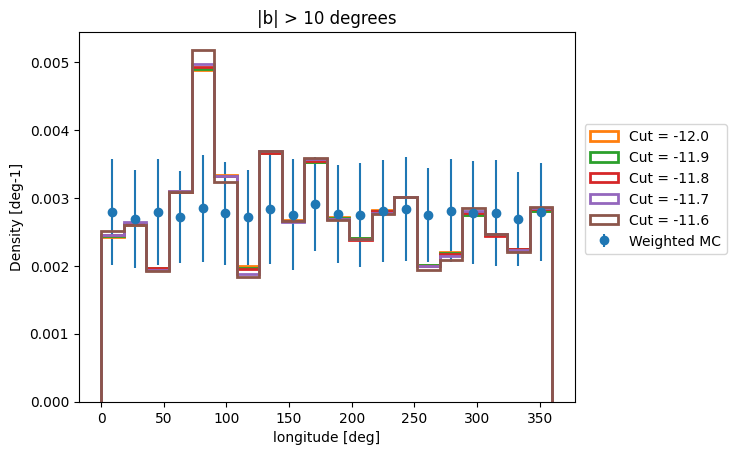

In [10]:
perform_cuts_studies(name_cat="table-4LAC-DR3-h.fits")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


Text(0.5, 0, 'Angular distance between blazar pairs [deg]')

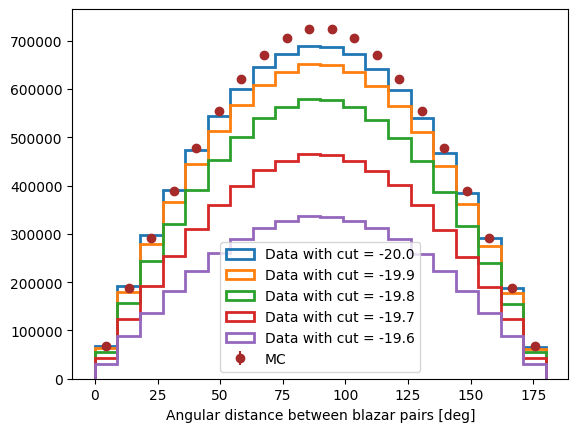

In [9]:
def get_ang_dists(rnd_lat, rnd_lon):
    ang_seps = list()
    for i, (lon, lat) in enumerate(zip(rnd_lon, rnd_lat)):
        rnd_lon_rad_reduced = np.delete(rnd_lon, i)
        rnd_lat_rad_reduced = np.delete(rnd_lat, i)
        ang_sep = np.rad2deg(
            angular_separation(
                lat,
                lon,
                rnd_lat_rad_reduced,
                rnd_lon_rad_reduced,
            )
        )
        ang_seps.append(ang_sep)
    ang_seps = np.concatenate(ang_seps)
    return ang_seps

name_cat = "table-4LAC-DR2-h.fits"
alertstack_data_dir = "../../alertstack/data/"
with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])

blazars_cuts = []
for i in range(5):
    cut_e = -12. + 0.1*i
    print(f"cut_e: {cut_e}")
    mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
    blazars_cut = np.array(blazars[mask_e])
    blazars_cuts.append(blazars_cut)

mc_ang_seps = list()
for j in range(50):
    print(j)
    rnd_lon = uniform.rvs(
        size=int(len(blazars["GLON"]))
    ) * 360.
    rnd_lat_pos = uniform.rvs(
        size=int(len(blazars["GLAT"])/2.)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
    addition = 0
    if len(blazars["GLAT"])%2 != 0.:
        addition = 1
    rnd_lat_neg = - ( uniform.rvs(
        size=int(len(blazars["GLAT"])/2.  + addition)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
    rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
    
    rnd_lon_rad = np.deg2rad(np.array(rnd_lon))
    rnd_lat_rad = np.asin(np.array(rnd_lat))
    
    ang_seps = get_ang_dists(rnd_lon_rad, rnd_lat_rad)
    vals, quantiles, _ = plt.hist(ang_seps, bins=20, range=(0,180))
    plt.close()
    mc_ang_seps.append(vals)
    xs = (quantiles[:-1] + quantiles[1:])/2.

mc_ang_seps = np.array(mc_ang_seps)
mc_means = np.array([np.mean(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
mc_stds = np.array([np.std(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])

Text(0.5, 0, 'Angular distance between blazar pairs [deg]')

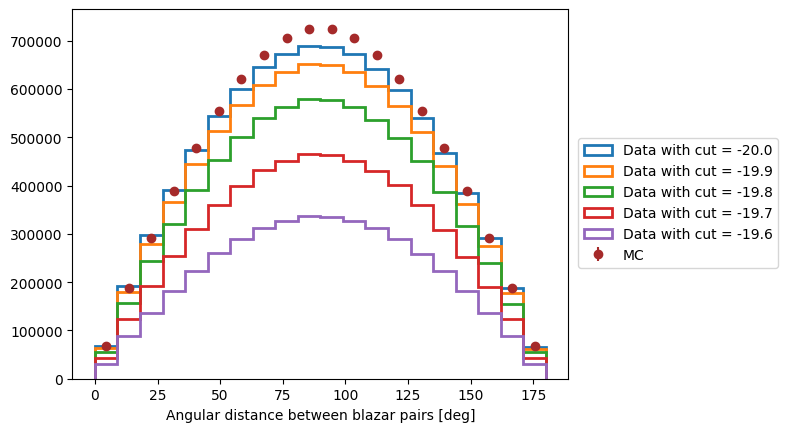

In [16]:
for i, cat in enumerate(blazars_cuts):
    cut = -20.0 + i * 0.1
    ang_seps_real = get_ang_dists(
        np.deg2rad(cat["GLON"]),
        np.deg2rad(cat["GLAT"])
    )
    plt.hist(
        ang_seps_real, bins=20, range=(0,180), histtype='step', linewidth=2,
        label=f"Data with cut = {cut}"
    )
plt.errorbar(
    xs, mc_means, mc_stds, marker='o', linestyle='', color="brown",
    label="MC"
)
plt.legend(loc=(1.02,0.3))
plt.xlabel("Angular distance between blazar pairs [deg]")

In [43]:
def get_ang_dists(rnd_lat, rnd_lon):
    ang_seps = list()
    for i, (lon, lat) in enumerate(zip(rnd_lon, rnd_lat)):
        rnd_lon_rad_reduced = np.delete(rnd_lon, i)
        rnd_lat_rad_reduced = np.delete(rnd_lat, i)
        ang_sep = np.rad2deg(
            angular_separation(
                lat,
                lon,
                rnd_lat_rad_reduced,
                rnd_lon_rad_reduced,
            )
        )
        ang_seps.append(ang_sep)
    ang_seps = np.concatenate(ang_seps)
    return ang_seps

def uniform_2d_test(name_cat="table_4LAC.fits", density=False):
    alertstack_data_dir = "../../alertstack/data/"
    with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
        cat = hdul[1].data
        header = hdul[1].header
    cat = np.sort(cat, order="Energy_Flux100")[::-1]
    
    #blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    
    mask = np.array([x["CLASS"] in blazar_class for x in cat])
    blazars = np.array(cat[mask])
    
    blazars_cuts = []
    for i in range(5):
        cut_e = -12. + 0.1*i
        print(f"cut_e: {cut_e}")
        mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
        blazars_cut = np.array(blazars[mask_e])
        blazars_cuts.append(blazars_cut)
    
    mc_ang_seps = list()
    mc_ang_seps_plot = list()
    for j in range(50):
        if j%10 == 0: print(j)
        rnd_lon = uniform.rvs(
            size=int(len(blazars["GLON"]))
        ) * 360.
        rnd_lat_pos = uniform.rvs(
            size=int(len(blazars["GLAT"])/2.)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
        addition = 0
        if len(blazars["GLAT"])%2 != 0.:
            addition = 1
        rnd_lat_neg = - ( uniform.rvs(
            size=int(len(blazars["GLAT"])/2.  + addition)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
        rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
        
        rnd_lon_rad = np.deg2rad(np.array(rnd_lon))
        rnd_lat_rad = np.asin(np.array(rnd_lat))
        
        ang_seps = get_ang_dists(rnd_lon_rad, rnd_lat_rad)
        vals, quantiles, _ = plt.hist(ang_seps, bins=20, range=(0,180), density=True)
        vals_plot, quantiles_plot, _ = plt.hist(ang_seps, bins=20, range=(0,180))
        plt.close()
        mc_ang_seps.append(vals)
        mc_ang_seps_plot.append(vals_plot)
        xs = (quantiles[:-1] + quantiles[1:])/2.
    
    mc_ang_seps = np.array(mc_ang_seps)
    mc_ang_seps_plot = np.array(mc_ang_seps_plot)
    mc_means = np.array([np.mean(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
    mc_stds = np.array([np.std(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
    mc_means_plot = np.array(
        [np.mean(mc_ang_seps_plot[:,i]) for i in range(len(mc_ang_seps_plot[0]))]
    )
    mc_stds_plot = np.array(
        [np.std(mc_ang_seps_plot[:,i]) for i in range(len(mc_ang_seps_plot[0]))]
    )
    
    
    for j, cat in enumerate(blazars_cuts):
        cut = -12.0 + j * 0.1
        ang_seps_real = get_ang_dists(
            np.deg2rad(cat["GLON"]),
            np.deg2rad(cat["GLAT"])
        )
        plt.hist(
            ang_seps_real,
            bins=20,
            range=(0,180),
            histtype='step',
            density=False,
            linewidth=2,
            label=f"Data with cut = {cut}"
        )    
    plt.errorbar(
        xs, mc_means_plot, mc_stds_plot, marker='o', linestyle='', color="brown",
        label="MC"
    )
    plt.legend(loc=(1.02,0.3))
    plt.xlabel("Angular distance between blazar pairs [deg]")
    plt.savefig(
        f"../../alertstack/data/2d_isotropy_{name_cat.split("table-")[-1].split(".")[0]}",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()
    for j, cat in enumerate(blazars_cuts):
        ang_seps_real = get_ang_dists(
            np.deg2rad(cat["GLON"]),
            np.deg2rad(cat["GLAT"])
        )
        real_vals, real_quantiles, _ = plt.hist(
            ang_seps_real,
            bins=20,
            range=(0,180),
            histtype='step',
            density=True
        )
        plt.close()
        chi_sq = np.sum(((real_vals-mc_means)/mc_stds)**2)
        pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(real_vals))
        print(f"cut: {-12.+j*0.1}, chi_sq: {chi_sq}, pval: {pval_chisq}")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


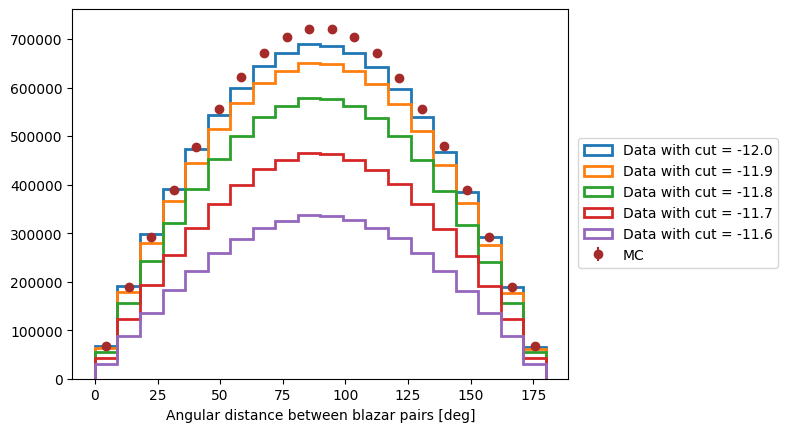

cut: -12.0, chi_sq: 341.79404706819713, pval: 0.0
cut: -11.9, chi_sq: 257.1162766979523, pval: 0.0
cut: -11.8, chi_sq: 121.20941554958173, pval: 2.220446049250313e-16
cut: -11.7, chi_sq: 51.01025305685194, pval: 0.0001584995058208083
cut: -11.6, chi_sq: 11.51797653135687, pval: 0.9316688280713092


In [44]:
uniform_2d_test(name_cat="table-4LAC-DR2-h.fits")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


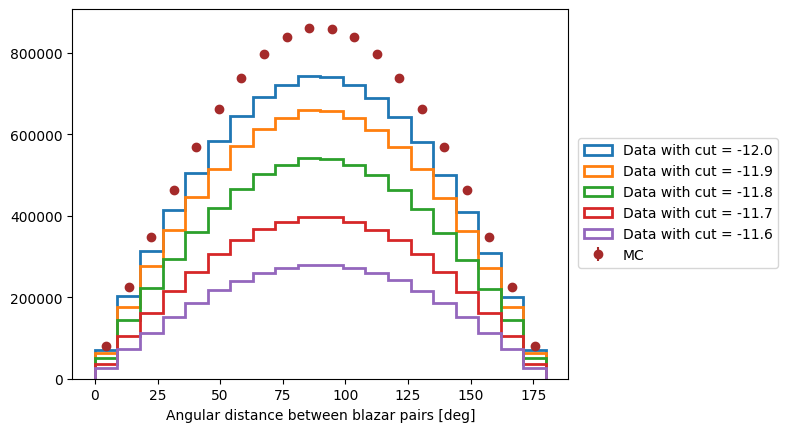

cut: -12.0, chi_sq: 215.53390025432842, pval: 0.0
cut: -11.9, chi_sq: 125.30406880735582, pval: 0.0
cut: -11.8, chi_sq: 40.537901856714086, pval: 0.004268549515724862
cut: -11.7, chi_sq: 17.46600756366194, pval: 0.6225394177237238
cut: -11.6, chi_sq: 28.08631462658313, pval: 0.10737181707673682


In [45]:
uniform_2d_test(name_cat="table-4LAC-DR3-h.fits")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


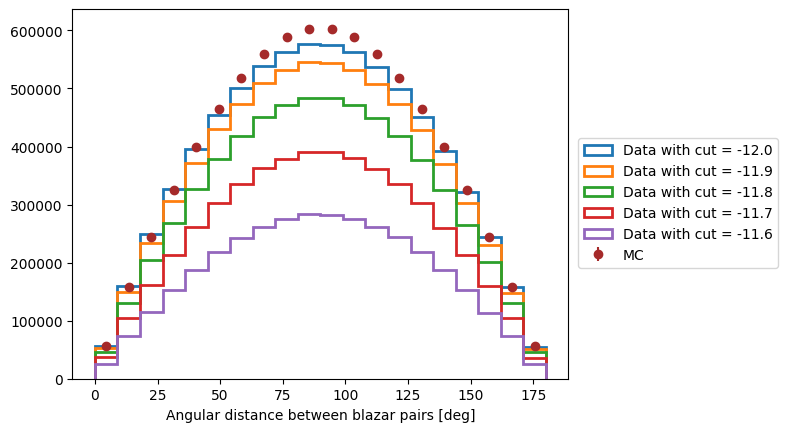

cut: -12.0, chi_sq: 261.08698030121565, pval: 0.0
cut: -11.9, chi_sq: 194.72110651024954, pval: 0.0
cut: -11.8, chi_sq: 95.63835069065847, pval: 7.53652695806295e-12
cut: -11.7, chi_sq: 38.807129049141125, pval: 0.007045264335624357
cut: -11.6, chi_sq: 8.203096043924441, pval: 0.9904365651151679


In [46]:
uniform_2d_test()

In [72]:
help(np.asin)

Help on ufunc in module numpy:

arcsin = <ufunc 'arcsin'>
    arcsin(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Inverse sine, element-wise.

    Parameters
    ----------
    x : array_like
        `y`-coordinate on the unit circle.
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument) must have length equal to the number of outputs.
    where : array_like, optional
        This condition is broadcast over the input. At locations where the
        condition is True, the `out` array will be set to the ufunc result.
        Elsewhere, the `out` array will retain its original value.
        Note that if an uninitialized `out` array is created via the default
        ``out=

In [45]:
from astropy.coordinates import angular_separation

np.rad2deg(
    angular_separation(
        np.deg2rad(rnd_lat),
        np.deg2rad(rnd_lon),
        np.deg2rad(rnd_lat),
        np.deg2rad(rnd_lon),
    )
)

array([0., 0., 0., ..., 0., 0., 0.], shape=(1916,))

cut_e: -11.6


(array([0.00252293, 0.00259259, 0.00172464, 0.00327288, 0.00525651,
        0.00303589, 0.00182699, 0.00371653, 0.00253451, 0.00364979,
        0.0027114 , 0.00244403, 0.00254565, 0.00317106, 0.00208359,
        0.00195207, 0.0026186 , 0.00259666, 0.00226172, 0.00307331]),
 array([2.23831236e-01, 1.82122459e+01, 3.62006607e+01, 5.41890755e+01,
        7.21774902e+01, 9.01659088e+01, 1.08154320e+02, 1.26142731e+02,
        1.44131149e+02, 1.62119568e+02, 1.80107986e+02, 1.98096390e+02,
        2.16084808e+02, 2.34073227e+02, 2.52061630e+02, 2.70050079e+02,
        2.88038483e+02, 3.06026886e+02, 3.24015320e+02, 3.42003723e+02,
        3.59992157e+02]),
 [<matplotlib.patches.Polygon at 0x7f35f6a48e60>])

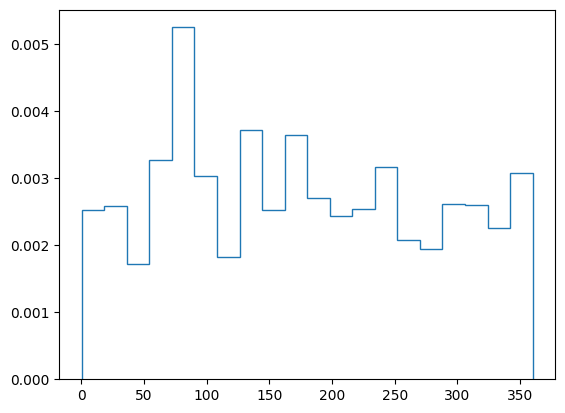

In [26]:
name_cat = "table_4LAC.fits"
alertstack_data_dir = "../../alertstack/data/"
with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])

cut_e = -12. + 0.1*4
print(f"cut_e: {cut_e}")
mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
blazars_cut = np.array(blazars[mask_e])

plt.hist(
    blazars_cut["GLON"],
    bins=20, histtype='step', density=True, weights=blazars_cut["Energy_Flux100"]
    #label=f"{cut_e} {round(pval,2):.2f}", linewidth=2,
)

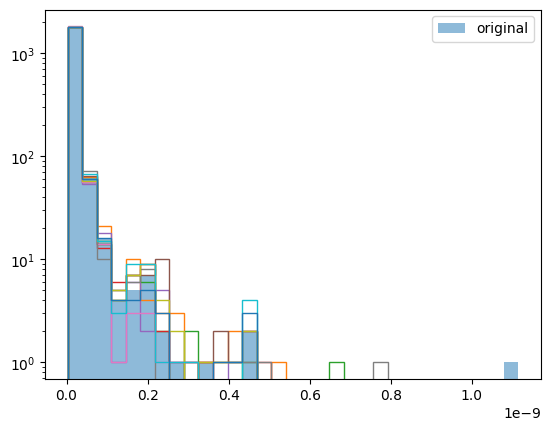

In [27]:
logbins = np.logspace(
    np.log10(np.min(blazars_cut["Energy_Flux100"])),
    np.log10(np.max(blazars_cut["Energy_Flux100"])),
    30
)
energyrange = (
    np.min(blazars_cut["Energy_Flux100"]),
    np.max(blazars_cut["Energy_Flux100"])
)
plt.hist(
    blazars_cut["Energy_Flux100"],
    bins=31,
    range=energyrange,
    alpha=0.5,
    label="original"
)

cdf = stats.ecdf(blazars_cut["Energy_Flux100"]).cdf
probs = cdf.probabilities[:-1] - cdf.probabilities[1:]

for i in range(10):
    plt.hist(
        stats.rv_histogram((probs, cdf.quantiles)).rvs(size=len(blazars_cut)),
        bins=31, histtype='step',
        range=energyrange
    )

#plt.xscale("log")
plt.yscale("log")
plt.legend()

<ErrorbarContainer object of 3 artists>

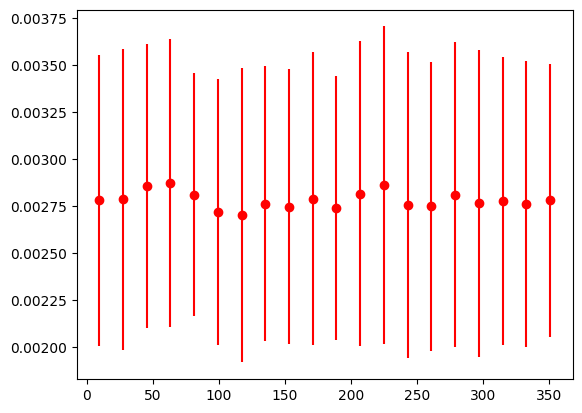

In [11]:
means, stds, xs = weighted_means_stds(blazars_cut)

plt.errorbar(
    xs,
    means, stds, color = "red", marker='o',
    linestyle="",
)

array([0.00336006, 0.00324472, 0.00225066, 0.00124083, 0.00316999,
       0.00214798, 0.00200252, 0.00392906, 0.00297752, 0.00359768])

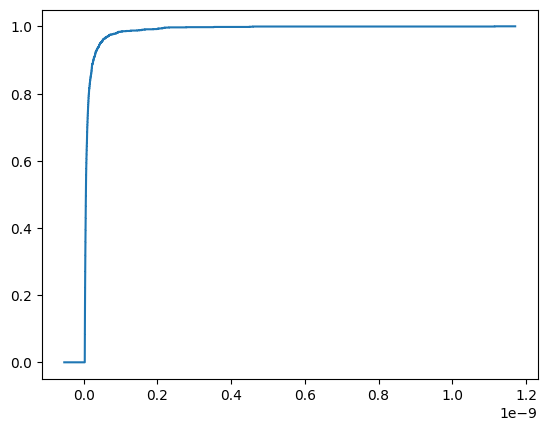

In [20]:
stats.ecdf(blazars_cut["Energy_Flux100"]).cdf.plot()

In [24]:
cdf = stats.ecdf(blazars_cut["Energy_Flux100"]).cdf
uniform.rvs()

np.float64(0.15504080335973525)

In [33]:
cdf.evaluate(0.1e-10)

array(0.70037927)

In [40]:
ecdf = stats.ecdf(blazars_cut["Energy_Flux100"])
ecdf.sf.evaluate(0.1e-10)

array(0.29962073)

In [45]:
probs = cdf.probabilities[:-1] - cdf.probabilities[1:]

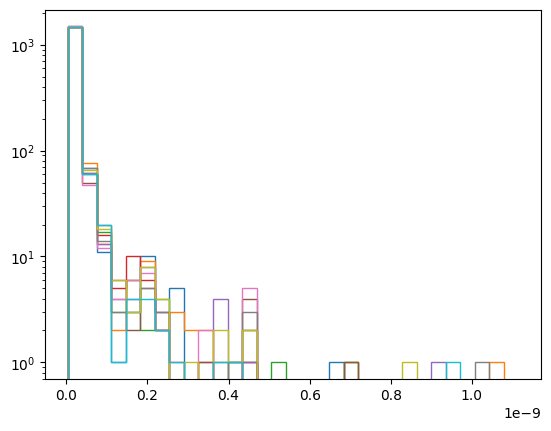